# Production-style PPS Statistical Test — Processed Session

Run the frozen statistical pipeline for Processed windows in one complete session with `M=39`, `n_jobs=6`, and `master_seed=2026`. Raw windows are excluded. The notebook validates identity coverage, runs the core, performs technical integrity checks, and saves exactly two session CSV files.

In [1]:
# TASK 1 - Imports, paths, and production settings
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start):
    """Find the repository root from the current directory."""
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "phase1" / "src").is_dir():
            return path
    raise FileNotFoundError("Cannot locate the project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
PHASE1_ROOT = PROJECT_ROOT / "phase1"
DATA_DIR = PHASE1_ROOT / "segmentated_data" / "dhdata"
RHO_DIR = (
    PHASE1_ROOT
    / "results"
    / "pps"
    / "pps_radius_calibration"
    / "csv"
)
OUTPUT_DIR = (
    PHASE1_ROOT / "results" / "statistic" / "processed"
)

if str(PHASE1_ROOT) not in sys.path:
    sys.path.insert(0, str(PHASE1_ROOT))

from src.dataloader.loader import get_data
from src.surrogates.statistic_test import (
    METRIC_NAMES,
    SURROGATE_CONFIG,
    run_session_test,
)

SESSION_ID = 17
WINDOW_SIZES = (60, 120, 180)
REPRESENTATIONS = ("Processed",)
STATE_BATCHES = (("Awake", 0), ("Drowsy", 1))
STATIONARITY = {"Processed": "processed"}
IDENTITY_COLUMNS = [
    "session",
    "representation",
    "state",
    "window_size",
    "window_id",
]
MASTER_SEED = 2026
N_JOBS = 6
EXPECTED_M = 39

assert SURROGATE_CONFIG["M"] == EXPECTED_M


In [2]:
# TASK 2 - Define loader-based session preparation
def append_batch_records(
    records,
    session_id,
    representation,
    state,
    batches,
):
    """Append one eligible representation-state cohort."""
    signal_key = representation.lower()
    for window_size in WINDOW_SIZES:
        batch = batches[window_size]
        for index, signal in enumerate(batch[signal_key]):
            records.append(
                {
                    "session": int(session_id),
                    "representation": representation,
                    "state": state,
                    "window_size": int(window_size),
                    "window_id": int(batch["window_id"][index]),
                    "signal": np.asarray(signal, dtype=float),
                    "sampling_rate": float(batch["fs"]),
                }
            )


def load_session_windows(session_id):
    """Load all frozen eligible windows for one session."""
    session_file = f"sample_{session_id}.csv"
    records = []

    for representation in REPRESENTATIONS:
        state_data = get_data(
            session_file,
            data_dir=DATA_DIR,
            window_sizes=WINDOW_SIZES,
            stationarity=STATIONARITY[representation],
        )
        for state, state_index in STATE_BATCHES:
            append_batch_records(
                records,
                session_id,
                representation,
                state,
                state_data[state_index],
            )

    windows = pd.DataFrame.from_records(records)
    if windows.empty:
        raise ValueError("No eligible windows were loaded.")
    return windows


In [3]:
# TASK 3 - Load eligible signals and frozen rho lookup
windows_df = load_session_windows(SESSION_ID)
rho_path = RHO_DIR / f"pps_radius_session_{SESSION_ID:02d}.csv"
rho_lookup_df = pd.read_csv(rho_path)
rho_lookup_df = rho_lookup_df.loc[
    rho_lookup_df["representation"].eq("Processed")
].copy()

print(f"Loaded signals: {len(windows_df):,}")
print(f"Loaded rho rows: {len(rho_lookup_df):,}")
print(f"Rho source: {rho_path}")


Loaded signals: 74
Loaded rho rows: 74
Rho source: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\pps\pps_radius_calibration\csv\pps_radius_session_17.csv


## Pre-run validation

In [4]:
# TASK 4 - Audit cohort counts and identity coverage
window_duplicates = int(
    windows_df.duplicated(IDENTITY_COLUMNS, keep=False).sum()
)
lookup_duplicates = int(
    rho_lookup_df.duplicated(IDENTITY_COLUMNS, keep=False).sum()
)
duplicate_identities = window_duplicates + lookup_duplicates
boundary_flags = (
    rho_lookup_df["boundary_flag"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("true")
)
boundary_count = int(boundary_flags.sum())
coverage = windows_df[IDENTITY_COLUMNS].merge(
    rho_lookup_df[IDENTITY_COLUMNS],
    on=IDENTITY_COLUMNS,
    how="outer",
    indicator=True,
)
missing_rho = int(coverage["_merge"].eq("left_only").sum())
extra_rho = int(coverage["_merge"].eq("right_only").sum())

pre_run_summary = pd.Series(
    {
        "Session ID": SESSION_ID,
        "Total eligible windows": len(windows_df),
        "Processed windows": int(
            windows_df["representation"].eq("Processed").sum()
        ),
        "Raw windows": int(
            windows_df["representation"].eq("Raw").sum()
        ),
        "Awake windows": int(windows_df["state"].eq("Awake").sum()),
        "Drowsy windows": int(
            windows_df["state"].eq("Drowsy").sum()
        ),
        "60 s windows": int(windows_df["window_size"].eq(60).sum()),
        "120 s windows": int(
            windows_df["window_size"].eq(120).sum()
        ),
        "180 s windows": int(
            windows_df["window_size"].eq(180).sum()
        ),
        "rho lookup rows": len(rho_lookup_df),
        "missing rho matches": missing_rho,
        "extra rho matches": extra_rho,
        "duplicate window identities": duplicate_identities,
        "boundary_flag=True count": boundary_count,
    },
    name="value",
)
display(pre_run_summary.to_frame())
assert missing_rho == 0, "Missing frozen rho matches."
assert extra_rho == 0, "Rho lookup contains ineligible windows."
assert duplicate_identities == 0, "Duplicate identities detected."
assert boundary_count == 0, "Unresolved boundary cases detected."
assert len(windows_df) == len(rho_lookup_df)
print("Pre-run validation: PASS")


,value
Session ID,17
Total eligible windows,74
Processed windows,74
Raw windows,0
Awake windows,51
Drowsy windows,23
60 s windows,42
120 s windows,19
180 s windows,13
rho lookup rows,74


Pre-run validation: PASS


## Production run

In [5]:
# TASK 5 - Run the frozen statistical core
run_started = time.perf_counter()
run_error = None
try:
    window_results, surrogate_results = run_session_test(
        windows_df=windows_df,
        rho_lookup_df=rho_lookup_df,
        session_id=SESSION_ID,
        master_seed=MASTER_SEED,
        n_jobs=N_JOBS,
        fail_fast=True,
    )
except Exception as exc:
    run_error = exc
    window_results = pd.DataFrame()
    surrogate_results = pd.DataFrame()
total_runtime = time.perf_counter() - run_started
print(f"Total runtime: {total_runtime:.2f} s")
if run_error is not None:
    print(f"Core failure: {type(run_error).__name__}: {run_error}")


Session 17
Windows: 74
Workers: 6
M: 39


Completed: 1 / 74 | Elapsed: 77.0 s | Average/window: 77.0 s | Estimated remaining: 5620.2 s


Completed: 4 / 74 | Elapsed: 78.5 s | Average/window: 19.6 s | Estimated remaining: 1373.6 s


Completed: 8 / 74 | Elapsed: 162.5 s | Average/window: 20.3 s | Estimated remaining: 1340.6 s


Completed: 12 / 74 | Elapsed: 164.4 s | Average/window: 13.7 s | Estimated remaining: 849.2 s


...

Completed: 60 / 74 | Elapsed: 1430.5 s | Average/window: 23.8 s | Estimated remaining: 333.8 s


Completed: 64 / 74 | Elapsed: 1472.3 s | Average/window: 23.0 s | Estimated remaining: 230.0 s


Completed: 68 / 74 | Elapsed: 1625.5 s | Average/window: 23.9 s | Estimated remaining: 143.4 s


Completed: 72 / 74 | Elapsed: 1847.7 s | Average/window: 25.7 s | Estimated remaining: 51.3 s


Completed: 74 / 74 | Elapsed: 1870.3 s | Average/window: 25.3 s | Estimated remaining: 0.0 s
Total runtime: 1870.35 s


In [6]:
# TASK 6 - Validate production outputs
n_windows = len(windows_df)
expected_surrogate_rows = n_windows * EXPECTED_M
window_failures = window_results.attrs.get("failures", [])
surrogate_failures = surrogate_results.attrs.get("failures", [])
if run_error is None:
    surrogate_counts = surrogate_results.groupby(
        IDENTITY_COLUMNS,
        observed=True,
    ).agg(
        rows=("surrogate_id", "size"),
        unique_surrogate_ids=("surrogate_id", "nunique"),
        unique_seeds=("seed", "nunique"),
    )
    window_metric_columns = [
        f"{metric}_{suffix}"
        for metric in METRIC_NAMES
        for suffix in (
            "original",
            "surrogate_mean",
            "surrogate_sd",
            "surrogate_median",
        )
    ]
    surrogate_metrics_finite = np.isfinite(
        surrogate_results[list(METRIC_NAMES)].to_numpy(dtype=float)
    ).all()
    window_metrics_finite = np.isfinite(
        window_results[window_metric_columns].to_numpy(dtype=float)
    ).all()
    all_metrics_finite = bool(
        surrogate_metrics_finite and window_metrics_finite
    )
    integrity_checks = {
        "core_completed": True,
        "window_rows_match": len(window_results) == n_windows,
        "surrogate_rows_match": (
            len(surrogate_results) == expected_surrogate_rows
        ),
        "39_rows_per_window": (
            surrogate_counts["rows"].eq(EXPECTED_M).all()
        ),
        "39_ids_per_window": (
            surrogate_counts["unique_surrogate_ids"]
            .eq(EXPECTED_M)
            .all()
        ),
        "39_seeds_per_window": (
            surrogate_counts["unique_seeds"]
            .eq(EXPECTED_M)
            .all()
        ),
        "all_metrics_finite": all_metrics_finite,
        "no_window_failures": not window_failures,
        "no_surrogate_failures": not surrogate_failures,
    }
else:
    all_metrics_finite = False
    integrity_checks = {"core_completed": False}
integrity_pass = bool(all(integrity_checks.values()))
display(
    pd.DataFrame(
        {
            "check": integrity_checks.keys(),
            "passed": integrity_checks.values(),
        }
    )
)
result = "PASS" if integrity_pass else "FAIL"
print(f"Post-run integrity: {result}")


,check,passed
0,core_completed,True
1,window_rows_match,True
2,surrogate_rows_match,True
3,39_rows_per_window,True
4,39_ids_per_window,True
5,39_seeds_per_window,True
6,all_metrics_finite,True
7,no_window_failures,True
8,no_surrogate_failures,True


Post-run integrity: PASS


In [7]:
# TASK 7 - Save exactly two production CSV files
window_output_path = (
    OUTPUT_DIR / f"session_{SESSION_ID}_pps_window_results.csv"
)
surrogate_output_path = (
    OUTPUT_DIR / f"session_{SESSION_ID}_pps_surrogate_results.csv"
)
outputs_saved = False
if integrity_pass:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    window_temp_path = window_output_path.with_suffix(".tmp")
    surrogate_temp_path = surrogate_output_path.with_suffix(".tmp")
    window_results.to_csv(window_temp_path, index=False)
    surrogate_results.to_csv(surrogate_temp_path, index=False)
    window_temp_path.replace(window_output_path)
    surrogate_temp_path.replace(surrogate_output_path)
    saved_window_rows = len(pd.read_csv(window_output_path))
    saved_surrogate_rows = len(pd.read_csv(surrogate_output_path))
    assert saved_window_rows == len(window_results)
    assert saved_surrogate_rows == len(surrogate_results)
    outputs_saved = True
    print(f"Saved: {window_output_path}")
    print(f"Saved: {surrogate_output_path}")
else:
    print("Output not saved because integrity checks failed.")


Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\statistic\processed\session_17_pps_window_results.csv
Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\statistic\processed\session_17_pps_surrogate_results.csv


## Technical summary

In [8]:
# TASK 8 - Print the final production summary
processed_count = int(
    windows_df["representation"].eq("Processed").sum()
)
raw_count = int(windows_df["representation"].eq("Raw").sum())
awake_count = int(windows_df["state"].eq("Awake").sum())
drowsy_count = int(windows_df["state"].eq("Drowsy").sum())
size_counts = windows_df["window_size"].value_counts()
failure_count = (
    int(run_error is not None)
    + len(window_failures)
    + len(surrogate_failures)
)
status = "PASS" if integrity_pass and outputs_saved else "FAIL"
print(f"Session: {SESSION_ID}")
print(f"Eligible windows: {n_windows}")
print(f"Processed / Raw: {processed_count} / {raw_count}")
print(f"Awake / Drowsy: {awake_count} / {drowsy_count}")
print(
    "60 / 120 / 180: "
    f"{int(size_counts.get(60, 0))} / "
    f"{int(size_counts.get(120, 0))} / "
    f"{int(size_counts.get(180, 0))}"
)
print(f"Window results rows: {len(window_results)}")
print(f"Surrogate results rows: {len(surrogate_results)}")
print(f"Expected surrogate rows: {expected_surrogate_rows}")
print(f"All metrics finite: {all_metrics_finite}")
print(f"Failures: {failure_count}")
print(f"Runtime: {total_runtime:.2f} s")
print(f"Average runtime/window: {total_runtime / n_windows:.2f} s")
print(f"Number of PPS realizations: {expected_surrogate_rows}")
print(f"Status: {status}")


Session: 17
Eligible windows: 74
Processed / Raw: 74 / 0
Awake / Drowsy: 51 / 23
60 / 120 / 180: 42 / 19 / 13
Window results rows: 74
Surrogate results rows: 2886
Expected surrogate rows: 2886
All metrics finite: True
Failures: 0
Runtime: 1870.35 s
Average runtime/window: 25.27 s
Number of PPS realizations: 2886
Status: PASS


# Session-level diagnostic — saved PPS statistical results

Analyze the saved Processed results for one session. This section does not regenerate PPS, apply multiple-testing correction, or make population-level conclusions.

In [1]:
# TASK 9 - Load the two saved production CSV files
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def locate_project_root(start):
    """Find the repository root from the current directory."""
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "phase1" / "src").is_dir():
            return path
    raise FileNotFoundError("Cannot locate the project root.")


ANALYSIS_SESSION_ID = 17
ANALYSIS_ROOT = locate_project_root(Path.cwd())
ANALYSIS_DIR = (
    ANALYSIS_ROOT
    / "phase1"
    / "results"
    / "statistic"
    / "processed"
)
WINDOW_CSV = (
    ANALYSIS_DIR
    / f"session_{ANALYSIS_SESSION_ID}_pps_window_results.csv"
)
SURROGATE_CSV = (
    ANALYSIS_DIR
    / f"session_{ANALYSIS_SESSION_ID}_pps_surrogate_results.csv"
)
PRIMARY_METRICS = ("CC", "DET", "LAM")
SECONDARY_METRICS = (
    "NRMSE",
    "Lmean",
    "ENTR",
    "Lmax",
    "TT",
    "Vmax",
)
ANALYSIS_METRICS = PRIMARY_METRICS + SECONDARY_METRICS
ANALYSIS_IDENTITY = [
    "session",
    "representation",
    "state",
    "window_size",
    "window_id",
]
analysis_windows = pd.read_csv(WINDOW_CSV)
analysis_surrogates = pd.read_csv(SURROGATE_CSV)
assert analysis_windows["representation"].eq("Processed").all()
assert analysis_surrogates["representation"].eq("Processed").all()
print(f"Window source: {WINDOW_CSV}")
print(f"Surrogate source: {SURROGATE_CSV}")


Window source: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\statistic\processed\session_17_pps_window_results.csv
Surrogate source: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\statistic\processed\session_17_pps_surrogate_results.csv


In [2]:
# TASK 10 - Validate saved-result integrity
surrogate_groups = analysis_surrogates.groupby(
    ANALYSIS_IDENTITY,
    observed=True,
).agg(
    rows=("surrogate_id", "size"),
    unique_surrogate_ids=("surrogate_id", "nunique"),
    unique_seeds=("seed", "nunique"),
)
window_numeric = analysis_windows.select_dtypes(include=np.number)
surrogate_metric_values = analysis_surrogates[
    list(ANALYSIS_METRICS)
].to_numpy(dtype=float)
integrity_diagnostic = pd.Series(
    {
        "window rows": len(analysis_windows),
        "surrogate rows": len(analysis_surrogates),
        "expected surrogate rows": len(analysis_windows) * 39,
        "unique window identities": (
            not analysis_windows.duplicated(ANALYSIS_IDENTITY).any()
        ),
        "39 surrogate rows per window": (
            surrogate_groups["rows"].eq(39).all()
        ),
        "39 unique surrogate_id per window": (
            surrogate_groups["unique_surrogate_ids"].eq(39).all()
        ),
        "39 unique seeds per window": (
            surrogate_groups["unique_seeds"].eq(39).all()
        ),
        "seeds globally unique": (
            analysis_surrogates["seed"].nunique()
            == len(analysis_surrogates)
        ),
        "window numeric values finite": (
            np.isfinite(window_numeric.to_numpy(dtype=float)).all()
        ),
        "surrogate metrics finite": (
            np.isfinite(surrogate_metric_values).all()
        ),
        "production failures": 0,
    },
    name="result",
)
display(integrity_diagnostic.to_frame())
assert len(analysis_windows) == 74
assert len(analysis_surrogates) == 74 * 39
assert surrogate_groups["rows"].eq(39).all()
assert surrogate_groups["unique_surrogate_ids"].eq(39).all()
assert surrogate_groups["unique_seeds"].eq(39).all()
assert np.isfinite(window_numeric.to_numpy(dtype=float)).all()
assert np.isfinite(surrogate_metric_values).all()
print("Saved-result integrity: PASS")


,result
window rows,74
surrogate rows,2886
expected surrogate rows,2886
unique window identities,True
39 surrogate rows per window,True
39 unique surrogate_id per window,True
39 unique seeds per window,True
seeds globally unique,True
window numeric values finite,True
surrogate metrics finite,True


Saved-result integrity: PASS


In [3]:
# TASK 11 - Define metric diagnostic summaries
def summarize_metric_results(frame):
    """Summarize rejection, direction, p-value, and delta."""
    rows = []
    for metric in ANALYSIS_METRICS:
        reject = frame[f"{metric}_reject"].astype(bool)
        direction = frame[f"{metric}_direction"].value_counts()
        delta = (
            frame[f"{metric}_original"]
            - frame[f"{metric}_surrogate_median"]
        )
        positive = int(delta.gt(0).sum())
        negative = int(delta.lt(0).sum())
        ties = int(delta.eq(0).sum())
        non_ties = positive + negative
        dominant = "higher" if positive >= negative else "lower"
        consistency = (
            max(positive, negative) / non_ties
            if non_ties
            else np.nan
        )
        rows.append(
            {
                "metric": metric,
                "N total": len(frame),
                "N reject": int(reject.sum()),
                "rejection fraction": float(reject.mean()),
                "higher": int(direction.get("higher", 0)),
                "lower": int(direction.get("lower", 0)),
                "none": int(direction.get("none", 0)),
                "median p-value": float(
                    frame[f"{metric}_p"].median()
                ),
                "median original - surrogate median": float(
                    delta.median()
                ),
                "dominant delta direction": dominant,
                "direction consistency": consistency,
                "delta ties": ties,
            }
        )
    return pd.DataFrame(rows)


def summarize_by_group(frame, group_name):
    """Summarize every metric within one grouping factor."""
    grouped_rows = []
    for group_value, group in frame.groupby(group_name, observed=True):
        summary = summarize_metric_results(group)
        summary.insert(0, group_name, group_value)
        grouped_rows.append(summary)
    return pd.concat(grouped_rows, ignore_index=True)


overall_metric_summary = summarize_metric_results(analysis_windows)
primary_summary = overall_metric_summary.loc[
    overall_metric_summary["metric"].isin(PRIMARY_METRICS)
].reset_index(drop=True)
secondary_summary = overall_metric_summary.loc[
    overall_metric_summary["metric"].isin(SECONDARY_METRICS)
].reset_index(drop=True)
print("Primary metrics")
display(primary_summary)
print("Secondary metrics")
display(secondary_summary)


Primary metrics


,metric,N total,N reject,rejection fraction,higher,lower,none,median p-value,median original - surrogate median,dominant delta direction,direction consistency,delta ties
0,CC,74,43,0.581081,43,0,31,0.05,0.095188,higher,1.000000,0
1,DET,74,74,1.000000,74,0,0,0.05,0.151084,higher,1.000000,0
2,LAM,74,60,0.810811,0,60,14,0.05,-0.094087,lower,0.986486,0


Secondary metrics


,metric,N total,N reject,rejection fraction,higher,lower,none,median p-value,median original - surrogate median,dominant delta direction,direction consistency,delta ties
0,NRMSE,74,69,0.932432,0,69,5,0.050,-0.117048,lower,1.000000,0
1,Lmean,74,72,0.972973,72,0,2,0.050,1.104681,higher,1.000000,0
2,ENTR,74,73,0.986486,73,0,1,0.050,0.337631,higher,1.000000,0
3,Lmax,74,61,0.824324,61,0,13,0.050,46.000000,higher,1.000000,0
4,TT,74,68,0.918919,0,68,6,0.050,-0.110168,lower,1.000000,0
5,Vmax,74,9,0.121622,0,9,65,0.975,-1.000000,lower,0.952381,32


In [4]:
# TASK 12 - Summarize Awake, Drowsy, and window sizes
state_metric_summary = summarize_by_group(analysis_windows, "state")
size_metric_summary = summarize_by_group(
    analysis_windows,
    "window_size",
)
state_counts = analysis_windows["state"].value_counts()
size_counts = analysis_windows["window_size"].value_counts().sort_index()
print("Cohort sizes by state")
display(state_counts.rename("N windows").to_frame())
print("Full metric summary by state")
display(state_metric_summary)
print("Cohort sizes by window duration")
display(size_counts.rename("N windows").to_frame())
print("Full metric summary by window duration")
display(size_metric_summary)


Cohort sizes by state


,N windows
state,
Awake,51
Drowsy,23


Full metric summary by state


,state,metric,N total,N reject,rejection fraction,higher,lower,none,median p-value,median original - surrogate median,dominant delta direction,direction consistency,delta ties
0,Awake,CC,51,31,0.607843,31,0,20,0.05,0.104890,higher,1.000000,0
1,Awake,DET,51,51,1.000000,51,0,0,0.05,0.152421,higher,1.000000,0
2,Awake,LAM,51,41,0.803922,0,41,10,0.05,-0.091880,lower,0.980392,0
3,Awake,NRMSE,51,46,0.901961,0,46,5,0.05,-0.117442,lower,1.000000,0
4,Awake,Lmean,51,49,0.960784,49,0,2,0.05,1.100507,higher,1.000000,0
5,Awake,ENTR,51,50,0.980392,50,0,1,0.05,0.368618,higher,1.000000,0
6,Awake,Lmax,51,41,0.803922,41,0,10,0.05,46.000000,higher,1.000000,0
7,Awake,TT,51,46,0.901961,0,46,5,0.05,-0.121205,lower,1.000000,0
8,Awake,Vmax,51,4,0.078431,0,4,47,0.95,-1.000000,lower,0.933333,21
9,Drowsy,CC,23,12,0.521739,12,0,11,0.05,0.077655,higher,1.000000,0


Cohort sizes by window duration


,N windows
window_size,
60,42
120,19
180,13


Full metric summary by window duration


,window_size,metric,N total,N reject,rejection fraction,higher,lower,none,median p-value,median original - surrogate median,dominant delta direction,direction consistency,delta ties
0,60,CC,42,25,0.595238,25,0,17,0.05,0.109750,higher,1.000000,0
1,60,DET,42,42,1.000000,42,0,0,0.05,0.156764,higher,1.000000,0
2,60,LAM,42,33,0.785714,0,33,9,0.05,-0.115024,lower,0.976190,0
3,60,NRMSE,42,39,0.928571,0,39,3,0.05,-0.120722,lower,1.000000,0
4,60,Lmean,42,41,0.976190,41,0,1,0.05,1.143065,higher,1.000000,0
5,60,ENTR,42,41,0.976190,41,0,1,0.05,0.341759,higher,1.000000,0
6,60,Lmax,42,35,0.833333,35,0,7,0.05,41.500000,higher,1.000000,0
7,60,TT,42,38,0.904762,0,38,4,0.05,-0.127604,lower,1.000000,0
8,60,Vmax,42,5,0.119048,0,5,37,0.90,-1.000000,lower,0.923077,16
9,120,CC,19,11,0.578947,11,0,8,0.05,0.091653,higher,1.000000,0


In [5]:
# TASK 13 - Audit RQA diagnostics and numerical edge cases
rqa_diagnostic_fields = (
    "epsilon",
    "target_rr",
    "achieved_rr",
    "zero_distance_fraction",
    "rr_exact",
)
available_rqa_fields = [
    name
    for name in rqa_diagnostic_fields
    if name in analysis_windows.columns
]
missing_rqa_fields = [
    name
    for name in rqa_diagnostic_fields
    if name not in analysis_windows.columns
]
vmax_zero_sd = analysis_windows["Vmax_surrogate_sd"].eq(0)
all_reject_p_values = np.concatenate(
    [
        analysis_windows.loc[
            analysis_windows[f"{metric}_reject"],
            f"{metric}_p",
        ].to_numpy(dtype=float)
        for metric in ANALYSIS_METRICS
    ]
)
numerical_diagnostic = pd.Series(
    {
        "RQA diagnostic fields available": (
            ", ".join(available_rqa_fields) or "none"
        ),
        "RQA diagnostic fields missing": ", ".join(
            missing_rqa_fields
        ),
        "Vmax windows with surrogate SD = 0": int(
            vmax_zero_sd.sum()
        ),
        "Vmax zero-SD windows rejected": int(
            analysis_windows.loc[vmax_zero_sd, "Vmax_reject"].sum()
        ),
        "minimum observed p-value": float(
            min(
                analysis_windows[f"{metric}_p"].min()
                for metric in ANALYSIS_METRICS
            )
        ),
        "all rejection p-values equal 0.05": bool(
            np.allclose(all_reject_p_values, 0.05)
        ),
    },
    name="result",
)
display(numerical_diagnostic.to_frame())
print(
    "RQA tie-limited cases cannot be audited because the saved CSV "
    "does not contain threshold diagnostics."
)
print(
    "The Vmax zero-SD cases are finite discrete ties, not NaN/Inf "
    "failures."
)


,result
RQA diagnostic fields available,none
RQA diagnostic fields missing,"epsilon, target_rr, achieved_rr, zero_distance..."
Vmax windows with surrogate SD = 0,12
Vmax zero-SD windows rejected,8
minimum observed p-value,0.05
all rejection p-values equal 0.05,True


RQA tie-limited cases cannot be audited because the saved CSV does not contain threshold diagnostics.
The Vmax zero-SD cases are finite discrete ties, not NaN/Inf failures.


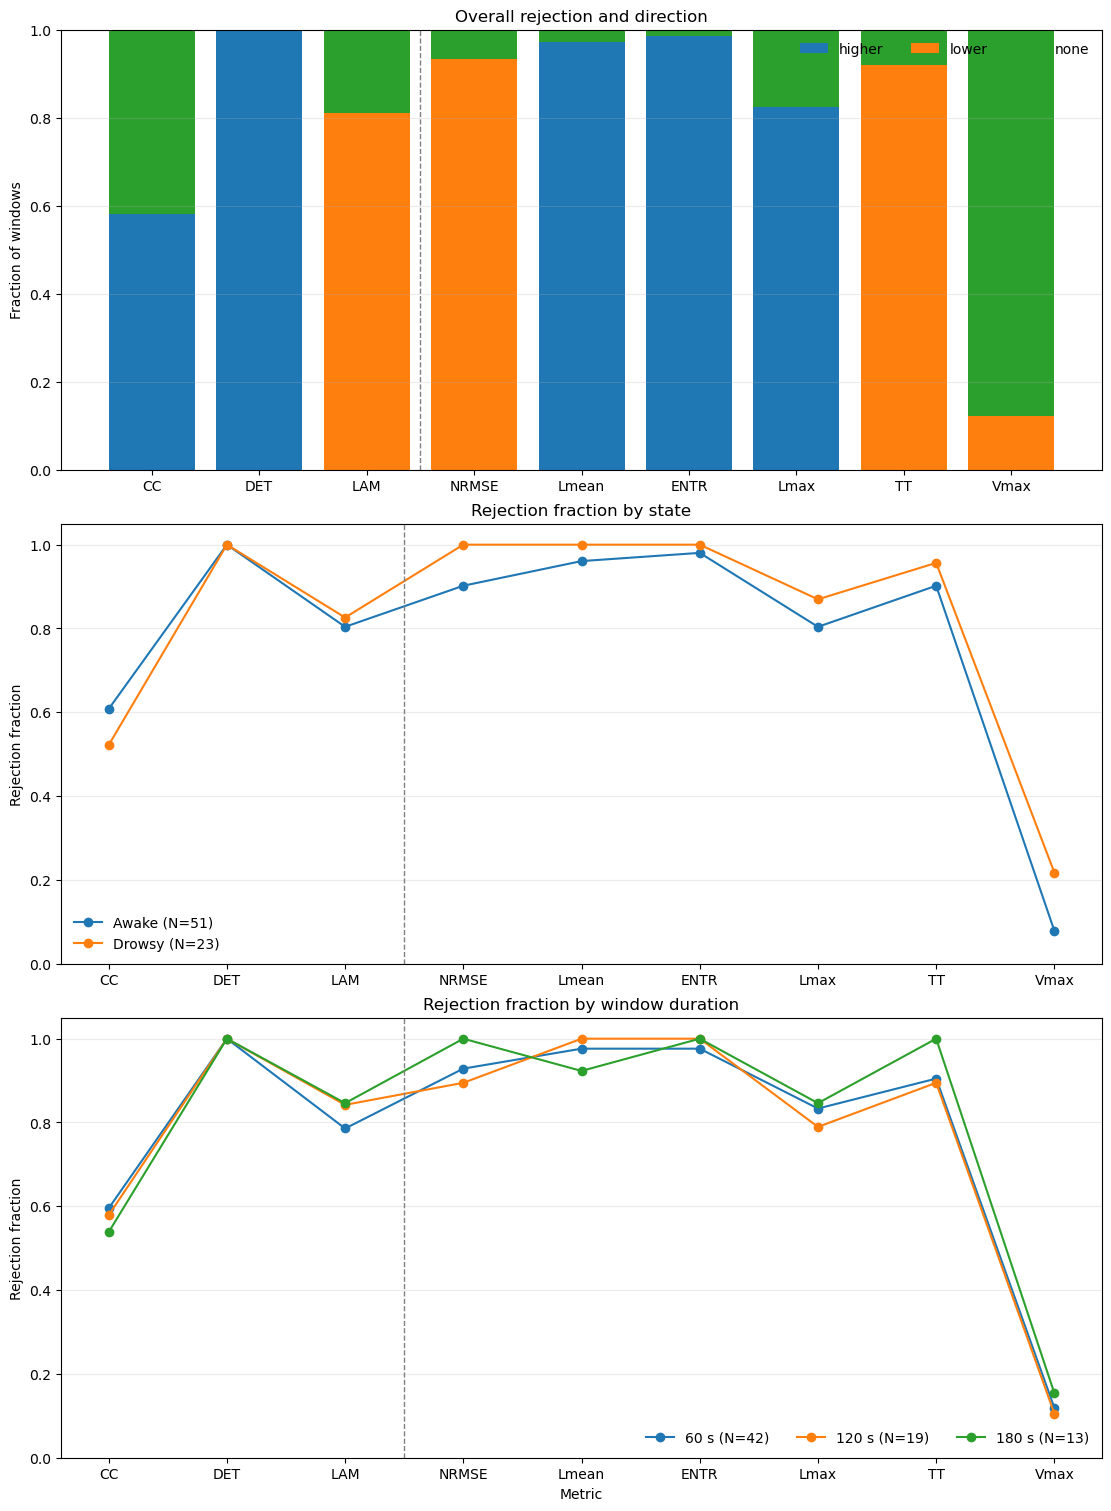

In [6]:
# TASK 14 - Plot rejection, state, and duration diagnostics
metric_labels = list(ANALYSIS_METRICS)
metric_positions = np.arange(len(metric_labels))
figure, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(11, 15),
    constrained_layout=True,
)

higher_fraction = (
    overall_metric_summary.set_index("metric").loc[
        metric_labels,
        "higher",
    ].to_numpy()
    / len(analysis_windows)
)
lower_fraction = (
    overall_metric_summary.set_index("metric").loc[
        metric_labels,
        "lower",
    ].to_numpy()
    / len(analysis_windows)
)
none_fraction = 1.0 - higher_fraction - lower_fraction
axes[0].bar(metric_positions, higher_fraction, label="higher")
axes[0].bar(
    metric_positions,
    lower_fraction,
    bottom=higher_fraction,
    label="lower",
)
axes[0].bar(
    metric_positions,
    none_fraction,
    bottom=higher_fraction + lower_fraction,
    label="none",
)
axes[0].set(
    title="Overall rejection and direction",
    ylabel="Fraction of windows",
    xticks=metric_positions,
    xticklabels=metric_labels,
    ylim=(0, 1),
)
axes[0].legend(ncols=3, frameon=False)

state_fraction = state_metric_summary.pivot(
    index="metric",
    columns="state",
    values="rejection fraction",
).loc[metric_labels]
for state in ("Awake", "Drowsy"):
    axes[1].plot(
        metric_positions,
        state_fraction[state],
        marker="o",
        label=f"{state} (N={int(state_counts[state])})",
    )
axes[1].set(
    title="Rejection fraction by state",
    ylabel="Rejection fraction",
    xticks=metric_positions,
    xticklabels=metric_labels,
    ylim=(0, 1.05),
)
axes[1].legend(frameon=False)

size_fraction = size_metric_summary.pivot(
    index="metric",
    columns="window_size",
    values="rejection fraction",
).loc[metric_labels]
for window_size in (60, 120, 180):
    axes[2].plot(
        metric_positions,
        size_fraction[window_size],
        marker="o",
        label=(
            f"{window_size} s "
            f"(N={int(size_counts[window_size])})"
        ),
    )
axes[2].set(
    title="Rejection fraction by window duration",
    xlabel="Metric",
    ylabel="Rejection fraction",
    xticks=metric_positions,
    xticklabels=metric_labels,
    ylim=(0, 1.05),
)
axes[2].legend(ncols=3, frameon=False)
for axis in axes:
    axis.axvline(2.5, color="0.5", linestyle="--", linewidth=1)
    axis.grid(axis="y", alpha=0.25)
plt.show()


## Concise session-level conclusion

- Integrity passes for 74 Processed windows and 2,886 surrogate rows; no NaN/Inf or production failure is present.
- DET rejects most often (74/74), followed by ENTR (73/74) and Lmean (72/74); Vmax rejects least often (9/74).
- Direction is highly consistent: CC, DET, Lmean, ENTR, and Lmax are higher in the original; NRMSE, LAM, TT, and rejected Vmax cases are lower.
- Awake and Drowsy retain the same dominant directions. Drowsy has descriptively higher rejection for most metrics except CC, but contains only 23 windows versus 51 Awake windows.
- No broad monotonic window-size effect is visible in rejection fractions. CC decreases mildly and LAM increases mildly with duration; the 180 s group has only 13 windows.
- Fixed-RR diagnostics are not stored in these CSVs, so epsilon, achieved RR, and tie-limited cases cannot be audited here. Twelve Vmax windows have zero surrogate SD, but all values remain finite.
- These findings describe Session 17 only and are not a population-level conclusion.